In [2]:
import pandas as pd


In [3]:
import os
print(os.listdir('./DataOps/Statics')) 

['irrigation_prediction.csv', 'irrigation_prediction_processed.csv', 'irrigation_prediction_Variables_Important.csv', 'mod.ipynb']


In [4]:
df = pd.read_csv('DataOps/Statics/irrigation_prediction.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                10000 non-null  object 
 1   Soil_pH                  10000 non-null  float64
 2   Soil_Moisture            10000 non-null  float64
 3   Organic_Carbon           10000 non-null  float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float64
 8   Sunlight_Hours           10000 non-null  float64
 9   Wind_Speed_kmh           10000 non-null  float64
 10  Crop_Type                10000 non-null  object 
 11  Crop_Growth_Stage        10000 non-null  object 
 12  Season                   10000 non-null  object 
 13  Irrigation_Type          10000 non-null  object 
 14  Water_Source           

In [6]:
df.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.487857,36.969207,0.944731,1.791963,26.991423,60.080339,1252.499420,7.518538,10.163545,7.598024,59.864122
std,0.979963,16.430845,0.372406,0.984202,8.664074,20.187973,715.582201,2.016077,5.670923,4.233919,34.483722
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.640000,22.860000,0.620000,0.940000,19.460000,42.855000,634.155000,5.760000,5.160000,3.950000,30.160000
50%,6.470000,37.240000,0.950000,1.780000,27.090000,60.040000,1250.335000,7.560000,10.190000,7.540000,59.630000
75%,7.350000,50.940000,1.260000,2.650000,34.500000,77.705000,1880.265000,9.260000,15.100000,11.202500,90.030000
max,8.200000,65.000000,1.600000,3.500000,42.000000,95.000000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [7]:
df.drop(columns=['Region','Water_Source','Water_Source','Season','Soil_Type','Region','Crop_Type'], inplace=True)

In [8]:
df_Variables_Important = df
df_Variables_Important.to_csv('DataOps/Statics/irrigation_prediction_Variables_Important.csv', index=False)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_pH                  10000 non-null  float64
 1   Soil_Moisture            10000 non-null  float64
 2   Organic_Carbon           10000 non-null  float64
 3   Electrical_Conductivity  10000 non-null  float64
 4   Temperature_C            10000 non-null  float64
 5   Humidity                 10000 non-null  float64
 6   Rainfall_mm              10000 non-null  float64
 7   Sunlight_Hours           10000 non-null  float64
 8   Wind_Speed_kmh           10000 non-null  float64
 9   Crop_Growth_Stage        10000 non-null  object 
 10  Irrigation_Type          10000 non-null  object 
 11  Field_Area_hectare       10000 non-null  float64
 12  Mulching_Used            10000 non-null  object 
 13  Previous_Irrigation_mm   10000 non-null  float64
 14  Irrigation_Need        

In [10]:
df['Irrigation_Type'].value_counts()

Irrigation_Type
Sprinkler    2527
Rainfed      2511
Drip         2495
Canal        2467
Name: count, dtype: int64

In [11]:
X = df.drop("Irrigation_Need", axis=1)
y = df["Irrigation_Need"]

In [12]:
from sklearn.preprocessing import StandardScaler
def preprocess_data(X):
    X_scaled = pd.get_dummies(X, drop_first=True)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_scaled)
    return X_scaled

In [13]:
def encoding_data(X):
    X_encoded = pd.get_dummies(X)
    return X_encoded

In [14]:
X_scaled= pd.DataFrame(preprocess_data(X.select_dtypes(include=['int64', 'float64'])),columns=X.select_dtypes(include=['int64', 'float64']).columns)
X_encoded = pd.DataFrame(encoding_data(X.select_dtypes(include=['object'])), columns=encoding_data(X.select_dtypes(include=['object'])).columns)
X_processed =pd.concat([X_scaled, X_encoded], axis=1)

In [15]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
y_encoded = pd.DataFrame(ordinal_encoder.fit_transform(y.values.reshape(-1, 1)), columns=['Irrigation_Need'])

In [16]:
from imblearn.over_sampling import RandomOverSampler

X_processed, y_encoded = RandomOverSampler().fit_resample(X_processed, y_encoded)

In [17]:
df['Mulching_Used'].value_counts()

Mulching_Used
No     5013
Yes    4987
Name: count, dtype: int64

In [18]:
X_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17592 entries, 0 to 17591
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Soil_pH                       17592 non-null  float64
 1   Soil_Moisture                 17592 non-null  float64
 2   Organic_Carbon                17592 non-null  float64
 3   Electrical_Conductivity       17592 non-null  float64
 4   Temperature_C                 17592 non-null  float64
 5   Humidity                      17592 non-null  float64
 6   Rainfall_mm                   17592 non-null  float64
 7   Sunlight_Hours                17592 non-null  float64
 8   Wind_Speed_kmh                17592 non-null  float64
 9   Field_Area_hectare            17592 non-null  float64
 10  Previous_Irrigation_mm        17592 non-null  float64
 11  Crop_Growth_Stage_Flowering   17592 non-null  bool   
 12  Crop_Growth_Stage_Harvest     17592 non-null  bool   
 13  C

In [19]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_processed, y_encoded)

importances = model.feature_importances_

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [20]:
import pandas as pd

feature_importance_df = pd.DataFrame({
    "feature": X_processed.columns,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(by="importance", ascending=False)

print(feature_importance_df)

                         feature  importance
1                  Soil_Moisture    0.214195
6                    Rainfall_mm    0.163833
4                  Temperature_C    0.115109
8                 Wind_Speed_kmh    0.106574
12     Crop_Growth_Stage_Harvest    0.062904
13      Crop_Growth_Stage_Sowing    0.061639
19              Mulching_Used_No    0.045163
20             Mulching_Used_Yes    0.043903
11   Crop_Growth_Stage_Flowering    0.036198
14  Crop_Growth_Stage_Vegetative    0.033941
7                 Sunlight_Hours    0.017041
10        Previous_Irrigation_mm    0.016417
5                       Humidity    0.016269
9             Field_Area_hectare    0.015127
0                        Soil_pH    0.015077
3        Electrical_Conductivity    0.015049
2                 Organic_Carbon    0.014369
16          Irrigation_Type_Drip    0.002031
15         Irrigation_Type_Canal    0.001907
18     Irrigation_Type_Sprinkler    0.001727
17       Irrigation_Type_Rainfed    0.001526


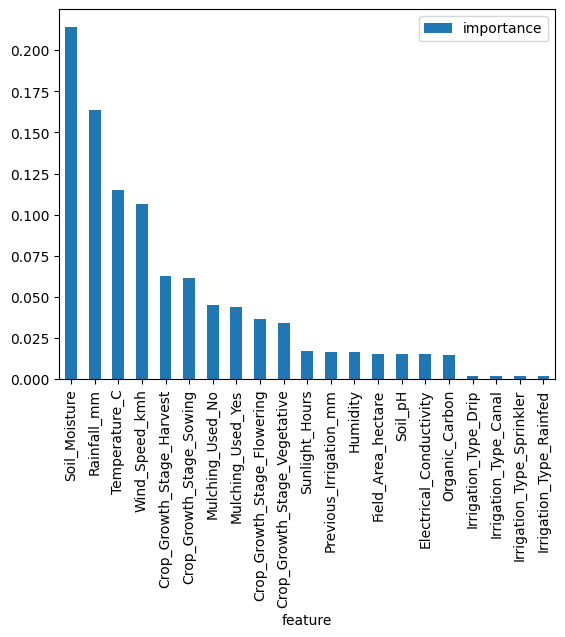

In [21]:
import matplotlib.pyplot as plt

feature_importance_df.plot(
    x="feature",
    y="importance",
    kind="bar"
)

plt.show()

L’analyse de l’importance des variables montre que l’humidité du sol est la variable la plus influente, 
suivie par les variables météorologiques telles que la température, les précipitations et la vitesse du vent.

Cela est cohérent avec les pratiques réelles d’irrigation, où l’humidité du sol et les conditions 
environnementales sont des facteurs clés pour déterminer les besoins en irrigation.

Les variables ayant une faible importance, telles que la région et la source d’eau, ont été supprimées 
afin d’améliorer les performances du modèle.

In [22]:
df_finnale = pd.concat([X_processed, y_encoded], axis=1)
df_finnale.to_csv('DataOps/Statics/irrigation_prediction_processed.csv', index=False)

In [23]:
df[df['Irrigation_Need'] == 'High']

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Growth_Stage,Irrigation_Type,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Irrigation_Need
10,5.36,11.85,1.48,2.11,35.21,73.29,1943.89,5.26,11.17,Flowering,Canal,13.11,No,74.35,High
73,5.09,9.60,0.56,2.60,20.66,45.12,252.73,6.08,13.32,Vegetative,Sprinkler,11.58,No,86.16,High
76,6.89,10.46,1.58,0.32,35.23,50.92,1214.95,10.29,16.67,Vegetative,Canal,2.58,No,38.17,High
101,6.76,11.29,1.47,0.52,41.82,78.36,117.09,10.59,16.32,Vegetative,Rainfed,10.84,No,57.71,High
114,5.77,20.35,0.37,0.67,39.64,73.41,293.45,10.89,18.26,Flowering,Drip,2.28,No,66.08,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9746,6.35,10.33,0.92,1.10,30.14,72.08,2069.81,7.49,15.61,Flowering,Rainfed,14.08,No,48.81,High
9760,6.74,21.28,0.64,1.63,26.94,38.94,21.19,8.13,12.32,Flowering,Sprinkler,6.54,No,22.39,High
9865,4.95,24.72,0.42,3.42,37.85,44.46,1419.95,10.96,16.49,Vegetative,Rainfed,8.57,No,112.36,High
9877,7.97,14.00,0.44,1.61,35.72,77.63,180.06,10.86,7.98,Flowering,Sprinkler,2.97,No,67.87,High


In [24]:
print(y_encoded.value_counts())

Irrigation_Need
0.0                5864
1.0                5864
2.0                5864
Name: count, dtype: int64


In [25]:
df_data_cleaned = pd.read_csv('DataOps/Statics/irrigation_prediction_processed.csv')
df.columns

Index(['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
       'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
       'Wind_Speed_kmh', 'Crop_Growth_Stage', 'Irrigation_Type',
       'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm',
       'Irrigation_Need'],
      dtype='object')